In [1]:
import torch
import tifffile as tiff
import cv2

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU Name: NVIDIA H100 NVL


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
input_file="./data/NYBD1-A10_250nM_BT549_site1_FITC_Day0.tiff"
output_dir="./data/png_converted"
os.makedirs(output_dir, exist_ok=True)

In [3]:
from aicsimageio import AICSImage
img = AICSImage(input_file)
print(f"Image Dimensions: {img.dims}")
print(f"Shape: {img.shape}")

Image Dimensions: <Dimensions [T: 1, C: 1, Z: 1, Y: 1040, X: 1392]>
Shape: (1, 1, 1, 1040, 1392)


Saved PNG to: ./data/png_converted/NYBD1-A10_250nM_BT549_site1_FITC_Day0.png


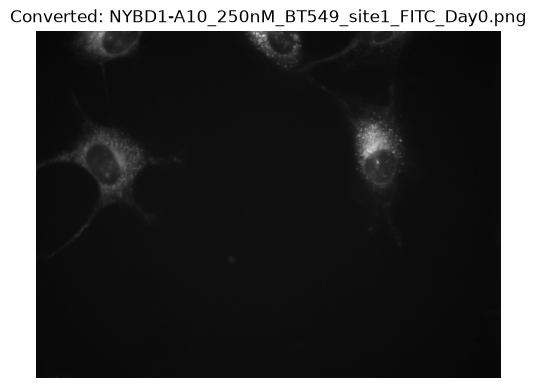

In [4]:
img_data = img.get_image_data("YX", T=0, C=0, Z=0) 

# 4. Process the image: Normalize to 8-bit for PNG
if img_data.dtype == np.uint16 or img_data.dtype == np.float32:
    img_norm = cv2.normalize(img_data, None, 0, 255, cv2.NORM_MINMAX)
    img_8bit = np.uint8(img_norm)
else:
    img_8bit = img_data

# 5. Save the converted image as PNG
base_name = os.path.splitext(os.path.basename(input_file))[0]
output_file = os.path.join(output_dir, f"{base_name}.png")

cv2.imwrite(output_file, img_8bit)

print(f"Saved PNG to: {output_file}")

# 6. Visualize the converted image
plt.figure(figsize=(6, 6))
plt.imshow(img_8bit, cmap='gray')
plt.title(f"Converted: {base_name}.png")
plt.axis('off')
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from aicsimageio import AICSImage
from tqdm import tqdm

# 1. Define paths
input_folder = "./data/tiff_files/NCI60 Images/breast/bt549/nybd1" # Folder containing your .tiff files
output_folder = "./data/png_converted/NCI60 Images/breast/bt549/nybd1" # Folder to save .png files

os.makedirs(output_folder, exist_ok=True)

# 2. Get a list of all .tiff files in the input folder
tiff_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.tiff', '.tif'))]

print(f"Found {len(tiff_files)} TIFF files to convert.")

# 3. Process files one by one
for filename in tqdm(tiff_files, desc="Converting TIFF to PNG"):
    try:
        # Construct full file paths
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, os.path.splitext(filename)[0] + ".png")
        
        # Load the image
        img = AICSImage(input_path)
        
        # Get image data (selecting first Time, Channel, Z-slice)
        # Note: If your data structure differs (e.g., has Z-stack), adjust T, C, Z indices accordingly
        img_data = img.get_image_data("YX", T=0, C=0, Z=0)
        
        # Normalize to 8-bit
        if img_data.dtype != np.uint8:
            img_norm = cv2.normalize(img_data, None, 0, 255, cv2.NORM_MINMAX)
            img_8bit = np.uint8(img_norm)
        else:
            img_8bit = img_data
            
        # Save as PNG
        cv2.imwrite(output_path, img_8bit)
        
    except Exception as e:
        print(f"\nError processing {filename}: {e}")

print("\nBatch conversion complete!")

Found 4480 TIFF files to convert.


Converting TIFF to PNG: 100%|██████████| 4480/4480 [04:45<00:00, 15.69it/s]


Batch conversion complete!
